# Linear Mixed Effects Analysis

In [ ]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
import pandas as pd
import numpy as np

import io
import pymc as pm
import arviz as az

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.stats import pearsonr

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

from Participant import Participant
# target emotion
# Multiclass classification

# # LOO CV
# df_file_path = r'target_emotion_multiclass\linear_3d_1_Single_40_0.1.csv'
# df1 = pd.read_csv(df_file_path)
# # Block CV
# df_file_path = r'target_emotion_multiclass\linear_3d_1_Blockwise_40_0.1.csv'
# df_file_path = r'target_emotion_multiclass\linear_3d_1_Single_40_0.1.csv'
# df2 = pd.read_csv(df_file_path)

# Binary classification
# df_file_path = r'target_emotion_binaryclass\linear_3d_1_Single_30_0.1.csv'

# relative to subject response
# df_file_path = r'emotion_response_multiclass\linear_3d_1_Single_30_0.1.csv'

# # LOO CV
# df_file_path = r'emotion_response_multiclass\linear_3d_1_Single_30_1.0.csv'
# df1 = pd.read_csv(df_file_path)

# # Block CV
# df_file_path = r'emotion_response_multiclass\linear_3d_1_Blockwise_30_0.1.csv'
# df2 = pd.read_csv(df_file_path)

# df = pd.read_csv(df_file_path)

In [572]:
df['accuracy'] = df['norm_loo_bal_acc']

In [713]:
df['accuracy'] = (df['block_bal_acc'] - 1/3) / (1 - 1/3)

In [195]:
df1['accuracy'] = df1['loo_bal_acc']
df1['block_cv'] = False
df2['accuracy'] = df2['block_bal_acc']
df2['block_cv'] = True
df = pd.concat([df1, df2], ignore_index=True)

In [658]:
df1['accuracy'] = df1['norm_loo_bal_acc']
df1['block_cv'] = False
df2['accuracy'] = df2['norm_block_bal_acc']
df2['block_cv'] = True
df = pd.concat([df1, df2], ignore_index=True)

##### Is VSA lower in high DIF?

In [561]:
result = []
for row_index in range(df.__len__()):
    data_string = df['df'].loc[row_index]
    id = df['id'].loc[row_index]
    condition = df['condition'].loc[row_index]
    data = pd.read_csv(io.StringIO(data_string), sep='\s+')

    if len(data) < 30:
        print(f"Skipping {id} in {condition}: Only {len(data)} rows. Need at least 30.")
        continue

    data = data[data['Emotion'] == 'Sadness']

    features = ['HR']
    X = data[features]
    y = data['Emotion']
    groups = data['Block'].values

    if len(np.unique(groups)) < 2:
        print(f"Skipping {id} in {condition}: Need at least 2 blocks for LOGO-CV.")
        continue

    # Single scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    result.append({
        'id': id,
        'condition': condition,
        'X': X_scaled,
    })

Skipping 1 in audio-only: Only 12 rows. Need at least 30.
Skipping 3 in audio-only: Only 21 rows. Need at least 30.
Skipping 3 in image-only: Only 24 rows. Need at least 30.
Skipping 4 in audio-only: Only 12 rows. Need at least 30.
Skipping 6 in audio-only: Only 12 rows. Need at least 30.
Skipping 8 in image-only: Only 16 rows. Need at least 30.
Skipping 8 in audio+image: Only 24 rows. Need at least 30.
Skipping 11 in audio-only: Only 12 rows. Need at least 30.
Skipping 12 in audio-only: Only 12 rows. Need at least 30.
Skipping 13 in audio-only: Only 12 rows. Need at least 30.
Skipping 14 in audio-only: Only 12 rows. Need at least 30.
Skipping 15 in audio-only: Only 12 rows. Need at least 30.
Skipping 17 in audio+image: Only 16 rows. Need at least 30.
Skipping 18 in audio-only: Only 12 rows. Need at least 30.
Skipping 18 in audio+image: Only 27 rows. Need at least 30.
Skipping 20 in audio-only: Only 12 rows. Need at least 30.
Skipping 20 in image-only: Only 12 rows. Need at least 30.
S

In [562]:
result
VSAs = []
for i in range(len(result)):
    for j in range(result[i]['X'].__len__()):
        VSAs.append(pd.DataFrame({
            'id': result[i]['id'],
            'ComEDA': result[i]['X'][j]
        }))

In [563]:
VSAs_df = pd.concat(VSAs)

In [564]:
for id in VSAs_df['id'].unique():
    p = Participant(id)

    VSAs_df.loc[VSAs_df['id'] == id, 'tas'] = p.tas_corrected    
    VSAs_df.loc[VSAs_df['id'] == id, 'eot'] = p.eot_corrected
    VSAs_df.loc[VSAs_df['id'] == id, 'ddf'] = p.ddf_corrected
    VSAs_df.loc[VSAs_df['id'] == id, 'dif'] = p.dif_corrected

                            OLS Regression Results                            
Dep. Variable:                 ComEDA   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                 2.270e-13
Date:                Tue, 02 Jun 2026   Prob (F-statistic):               1.00
Time:                        14:04:17   Log-Likelihood:                -1638.9
No. Observations:                1155   AIC:                             3282.
Df Residuals:                    1153   BIC:                             3292.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4.936e-16      0.180   2.74e-15      1.0

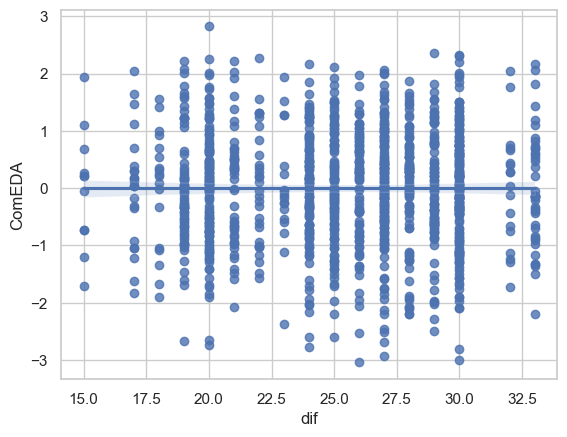

In [565]:
feature = 'ComEDA'
effect = 'dif'

model = smf.ols(f"{feature} ~ {effect}", data=VSAs_df).fit()

print(model.summary())

sns.regplot(data=VSAs_df, x=effect, y='ComEDA')
plt.show()

#####

In [714]:
for id in df['id'].unique():
    p = Participant(id)

    df.loc[df['id'] == id, 'age'] = p.age
    df.loc[df['id'] == id, 'gender'] = p.gender
    df.loc[df['id'] == id, 'tas'] = p.tas_corrected
    
    df.loc[df['id'] == id, 'eot'] = p.eot_corrected
    df.loc[df['id'] == id, 'ddf'] = p.ddf_corrected
    df.loc[df['id'] == id, 'dif'] = p.dif_corrected
    
    for condition in df['condition'].unique():
        mask = Participant(id).markers['condition'] == condition
        condition_markers = Participant(id).markers[mask]
        tmp = condition_markers[['target_emotion', 'emotion_response']].copy().dropna().reset_index(drop=True)
        behavioral_accuracy = np.array([row['target_emotion'] == row['emotion_response'] for _, row in tmp.iterrows()]).sum() / tmp.__len__()
        df.loc[(df['id'] == id) & (df['condition'] == condition), 'behavioral_accuracy'] = behavioral_accuracy

In [715]:
df['tas_minus_eot'] = df['tas'] - df['eot']

In [716]:
# df['te1vste2'] = df['te1'] + 'vs' + df['te2']

df['condition'] = df['condition'].str.replace(r'[+-]', '', regex=True)
df['condition'] = df['condition'].str.strip()

df['tas'] = (df['tas'] - 20)/(100 - 20)
# 8 items with 5-point Likert scale, so max score is 40
df['eot'] = (df['eot'] - 8)/(40 - 8)
# 5 items
df['ddf'] = (df['ddf'] - 5)/(25 - 5)
# 7 items
df['dif'] = (df['dif'] - 7)/(35 - 7)

df['tas_minus_eot'] = (df['tas_minus_eot'] - 12) / (60 - 12) 
df['dif'] = df['dif'] - 1/2
df['ddf'] = df['ddf'] - 1/2
df['eot'] = df['eot'] - 1/2


In [224]:
# df['accuracy'] = df['accuracy'] *100
df['block_bal_acc'] = df['block_bal_acc'] *100

In [ ]:
condition = 'imageonly'
# most effective condition was image-only
df = df[df['condition'] == condition]

fixed_effect = 'dif'
acc = 'accuracy'

In [313]:
df['group'] = df['id'] % 2

### Accuracy ~ TAS x Gender + (1 | Participant)

In [449]:
# Define the formula for Fixed Effects (Main effects + Interactions)
# We use * to include main effects and their interactions automatically
# formula = f"{acc} ~ {fixed_effect} * gender"
formula = f"accuracy ~ dif + block_cv"
# formula = f"block_bal_acc ~ dif"
# formula = f"{acc} ~ eot + dif + ddf"
# formula = f'{acc} ~ tas'
# formula = f"{acc} ~ eot*gender + dif*gender + ddf*gender"
# formula = f"{acc} ~ {fixed_effect} * condition"

# Fit the model
# groups: The variable that defines your clusters (SubjectID)
# re_formula: The variable that gets a random slope (Condition)
model = smf.mixedlm(formula, data=df, groups=df["id"])

result = model.fit()

# View the results
print(result.summary())

           Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  accuracy
No. Observations:    50       Method:              REML    
No. Groups:          25       Scale:               0.0204  
Min. group size:     2        Log-Likelihood:      14.3177 
Max. group size:     2        Converged:           Yes     
Mean group size:     2.0                                   
-----------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept         0.224    0.043  5.173 0.000  0.139  0.309
block_cv[T.True] -0.118    0.040 -2.928 0.003 -0.198 -0.039
dif              -0.306    0.178 -1.720 0.085 -0.655  0.043
Group Var         0.009    0.055                           



c:\Users\Mario Tokumori\.conda\envs\handeln2025\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [875]:
acc = 'block_bal_acc'

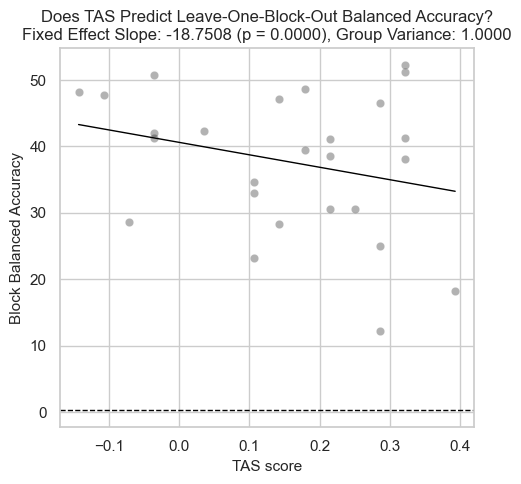

In [876]:
# 1. Set style
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(5, 5))

intercept = result.params["Intercept"]
slope = result.params[fixed_effect]
p_value = result.pvalues[fixed_effect]
chance_level = 1/3

sns.scatterplot(
    x=fixed_effect,
    y=acc,
    data=df,
    alpha=0.3,
    color='black',
    legend=False, 
    ax=ax,
)

x_vals = np.linspace(df[fixed_effect].min(), df[fixed_effect].max(), 100)
y_vals = intercept + slope * x_vals
ax.plot(
    x_vals,
    y_vals,
    color="black",
    linewidth=1,
)

# 5. chance reference line
ax.axhline(
    y=chance_level,
    color="black",
    linestyle="--",
    lw=1,
)

# Alexithymia threshold line
# ax.axvline(x=(51-20)/(100-20), color='black', linestyle=':', lw=1.5)
# ax.axvline(x=(60-20)/(100-20), color='black', linestyle=':', lw=1.5)

# 6. Formatting and Titles
title_string = (
    f"MixedLM: {acc.replace('_', ' ').title()} vs {fixed_effect.upper()}\n"
    f"Fixed Effect Slope: {slope:.4f} (p = {p_value:.4f}), Group Variance: {result.params['Group Var']:.4f}"
    )
title_string = (
    f"Does TAS Predict Leave-One-Block-Out Balanced Accuracy?\n"
    f"Fixed Effect Slope: {slope:.4f} (p = {p_value:.4f}), Group Variance: {result.params['Group Var']:.4f}"
)
ax.set_title(title_string, fontsize=12)
ax.set_xlabel('TAS score', fontsize=11)
ax.set_ylabel('Block Balanced Accuracy', fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

# --- 1. Increase Mesh Density for Smooth Warping ---
x_range = np.linspace(df[fixed_effect].min(), df[fixed_effect].max(), 50)
# Use a continuous range for Y during plotting to show the "twist" 
# even though the data is binary
y_range_plot = np.linspace(0, 1, 50) 
X, Y = np.meshgrid(x_range, y_range_plot)

# B0, B_male, B_tas, B_inter, _ = result.params
B0, B_male, B_tas, B_inter, _ = result.params

# The interaction formula: the twist happens in the (X * Y) term
Z = B0 + (B_tas * X) + (B_male * Y) + (B_inter * X * Y)

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# --- 2. Surface with better shading ---
surf = ax.plot_surface(X, Y, Z, alpha=0.6, cmap='viridis', 
                       linewidth=0, antialiased=True, rstride=1, cstride=1)

# --- 3. Add Contour Lines (The secret to seeing the warp) ---
# These lines show where the Z-value is constant. 
# On a flat plane, they are straight. On a warped plane, they curve.
ax.contour(X, Y, Z, zdir='z', offset=0, cmap='viridis', alpha=0.5)

# --- 4. Add "Ribs" (Wireframe) ---
# Plotting every 10th line helps the eye track the slope change
ax.plot_wireframe(X, Y, Z, color='black', alpha=0.1, rstride=10, cstride=10)

# 5. Plot the actual data points
colors = df['gender'].map({'Female': 'red', 'Male': 'blue'})
gender_numeric = df['gender'].map({'Female': 0, 'Male': 1})
ax.scatter(df[fixed_effect], gender_numeric, df[acc], 
           c=colors, s=60, alpha=0.7, edgecolor='white', linewidth=0.5)

# 6. Chance Level Plane
Z_chance = np.ones_like(X) * 0.5
ax.plot_surface(X, Y, Z_chance, alpha=0.1, color='gray')

# --- 7. Optimize Viewpoint ---
# A slight elevation and a 45-degree angle usually show "twist" best
ax.view_init(elev=25, azim=-60)

# Final formatting
ax.set_zlim(0, 1)
ax.set_ylim(0, 1)
ax.set_yticks([0, 1])
ax.set_xlim(df[fixed_effect].min(), df[fixed_effect].max())
ax.set_yticklabels(['Female', 'Male'])
ax.set_xlabel(f'{fixed_effect.upper()} Score')
ax.set_ylabel('Gender')
ax.set_zlabel('Balanced Accuracy')
ax.set_title(f'Interaction Surface: {fixed_effect.upper()} x Gender in {condition} Condition')

plt.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Predicted Accuracy')
plt.show()

In [42]:
from scipy.stats import shapiro, pearsonr, spearmanr

# List of genders to iterate through
genders = df['gender'].unique()

for g in genders:
    print(f"--- Analysis for Gender: {g} ---")
    
    # Filter the data
    group_data = df[df['gender'] == g]
    x = group_data[fixed_effect]
    y = group_data['block_bal_acc']
    
    # 1. Shapiro-Wilk Test for Normality
    stat_x, p_val_x = shapiro(x)
    stat_y, p_val_y = shapiro(y)
    
    print(f"Shapiro-Wilk Normality Check:")
    print(f"  {fixed_effect.upper()}: p = {p_val_x:.4f}")
    print(f"  Accuracy: p = {p_val_y:.4f}")
    
    # 2. Decision Logic: Pearson or Spearman?
    # If either variable is NOT normal (p < 0.05), use Spearman
    method = "Spearman (Rank-based)"
    coeff, p_corr = spearmanr(x, y)

    print(f"Resulting Correlation ({method}):")
    print(f"  Coefficient (r/rho): {coeff:.3f}")
    print(f"  P-value: {p_corr:.4f}")

    method = "Pearson (Linear)"
    coeff, p_corr = pearsonr(x, y)
        
    print(f"Resulting Correlation ({method}):")
    print(f"  Coefficient (r/rho): {coeff:.3f}")
    print(f"  P-value: {p_corr:.4f}\n")

--- Analysis for Gender: Male ---
Shapiro-Wilk Normality Check:
  DIF: p = 0.2476
  Accuracy: p = 0.9068
Resulting Correlation (Spearman (Rank-based)):
  Coefficient (r/rho): -0.042
  P-value: 0.8867
Resulting Correlation (Pearson (Linear)):
  Coefficient (r/rho): -0.201
  P-value: 0.4912

--- Analysis for Gender: Female ---
Shapiro-Wilk Normality Check:
  DIF: p = 0.4038
  Accuracy: p = 0.1271
Resulting Correlation (Spearman (Rank-based)):
  Coefficient (r/rho): -0.435
  P-value: 0.1575
Resulting Correlation (Pearson (Linear)):
  Coefficient (r/rho): -0.420
  P-value: 0.1740



In [64]:
from scipy.stats import shapiro, pearsonr, spearmanr, ttest_ind, mannwhitneyu, levene
# =====================================================================
# 2. BETWEEN-GENDER COMPARISON (The T-Test / Mann-Whitney Section)
# =====================================================================
print("=====================================================")
print("      BETWEEN-GENDER DIFFERENCE ANALYSIS            ")
print("=====================================================")

# Split into two distinct groups
group_male = df[df['gender'] == 'Male']
group_female = df[df['gender'] == 'Female']

# We will check differences for BOTH variables
variables_to_compare = [acc]



for var in variables_to_compare:
    print(f"\n--- Comparing groups for variable: {var.upper()} ---")
    
    male_vals = group_male[var]
    female_vals = group_female[var]
    
    # A. Check normality for both groups to decide on T-test vs Mann-Whitney
    _, p_norm_m = shapiro(male_vals)
    _, p_norm_f = shapiro(female_vals)
    
    print(f"Normality check -> Male p = {p_norm_m:.4f}, Female p = {p_norm_f:.4f}")
    
    stat, p_diff = mannwhitneyu(male_vals, female_vals, alternative='two-sided')
    print(f"Selected Test: Mann-Whitney U (Non-Parametric)")
    print(f"  U-statistic: {stat:.3f}")
    print(f"  P-value: {p_diff:.4f}")
    # Parametric path (T-test)
    # Check variance homogeneity (Levene's test) to set equal_var flag
    _, p_levene = levene(male_vals, female_vals)
    equal_variances = p_levene >= 0.05
        
    stat, p_diff = ttest_ind(male_vals, female_vals, equal_var=equal_variances)
    print(f"Selected Test: Independent Samples t-test (Parametric)")
    print(f"  Assumption: Equal Variances = {equal_variances} (Levene p = {p_levene:.4f})")
    print(f"  t-statistic: {stat:.3f}")
    print(f"  P-value: {p_diff:.4f}")
        
    # Quick mean report for descriptive context
    print(f"Descriptives -> Male Mean: {male_vals.mean():.4f}, Female Mean: {female_vals.mean():.4f}")

      BETWEEN-GENDER DIFFERENCE ANALYSIS            

--- Comparing groups for variable: BLOCK_BAL_ACC ---
Normality check -> Male p = 0.0925, Female p = 0.9106
Selected Test: Mann-Whitney U (Non-Parametric)
  U-statistic: 685.500
  P-value: 0.3640
Selected Test: Independent Samples t-test (Parametric)
  Assumption: Equal Variances = True (Levene p = 0.9285)
  t-statistic: 0.939
  P-value: 0.3511
Descriptives -> Male Mean: 0.5488, Female Mean: 0.5224


### OLS: Accuracy ~ TAS

In [708]:
fixed_effect = 'dif'

In [709]:
# result = smf.ols(f"{acc} ~ {fixed_effect} * gender", data=df).fit()
# result = smf.ols(f"norm_block_bal_acc ~ dif", data=df).fit()
result = smf.ols(f"accuracy ~ {fixed_effect}", data=df).fit()

print(result.summary())

                            OLS Regression Results                            
Dep. Variable:               accuracy   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                 -0.011
Method:                 Least Squares   F-statistic:                    0.6312
Date:                Sun, 07 Jun 2026   Prob (F-statistic):              0.433
Time:                        16:22:52   Log-Likelihood:                 22.608
No. Observations:                  35   AIC:                            -41.22
Df Residuals:                      33   BIC:                            -38.10
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1621      0.031      5.229      0.0

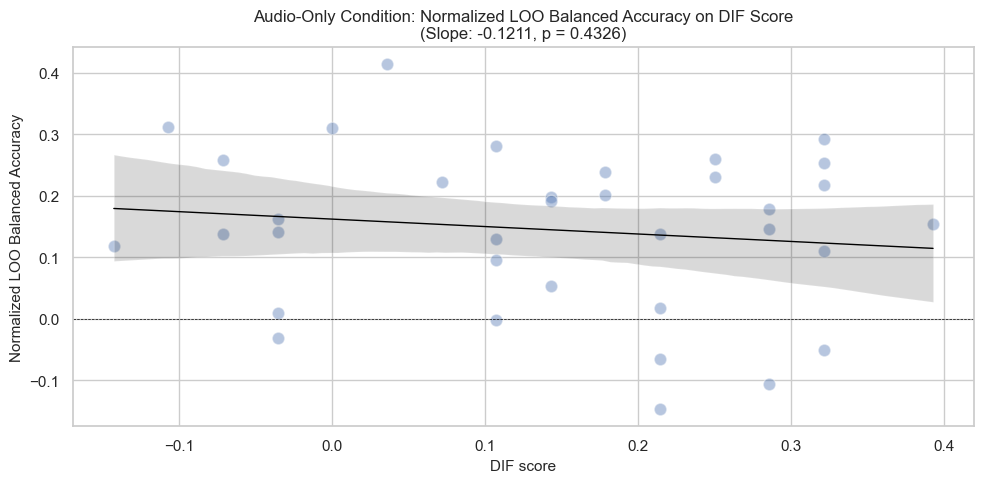

In [711]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Set the aesthetic style
sns.set_theme(style="whitegrid")

# 2. Create the figure
plt.figure(figsize=(10, 5))

# 3. Plot the data points and the regression line
# Seaborn's regplot will automatically calculate the best fit line 
# and a 95% confidence interval shadow.
sns.regplot(
    x=fixed_effect, 
    y=acc, 
    data=df, 
    scatter_kws={'alpha':0.4, 's':80, 'edgecolor':'white'},
    line_kws={'color':'black', 'lw':1}
)

chance_level = 0
plt.axhline(y=chance_level, color='black', linestyle='--', lw=0.5, label=f'Chance ({chance_level})')

# 4. Add labels and title using the coefficients from your summary
intercept = result.params['Intercept']
slope = result.params[fixed_effect]
p_value = result.pvalues[fixed_effect]

plt.title(f'Audio-Only Condition: Normalized LOO Balanced Accuracy on {fixed_effect.upper()} Score\n'
          f'(Slope: {slope:.4f}, p = {p_value:.4f})', fontsize=12)
# plt.title(f'Audio+Image Condition: Ordinary Least Squares Regression of Leave-One-Block-Out CV balanced accuracy vs TAS score\n(Slope: {slope:.4f}, p = {p_value:.4f})', fontsize=14)
plt.xlabel(f'{fixed_effect.upper()} score', fontsize=11)
plt.ylabel('Normalized LOO Balanced Accuracy', fontsize=11)

# 5. Optional: Set Y-axis limits if dealing with accuracy (0 to 1)
# plt.ylim(0, 0.6)
# plt.xlim(0., 0.9)

plt.tight_layout()
plt.show()

95% Confidence Interval for the slope: [-0.9388, 0.0881]


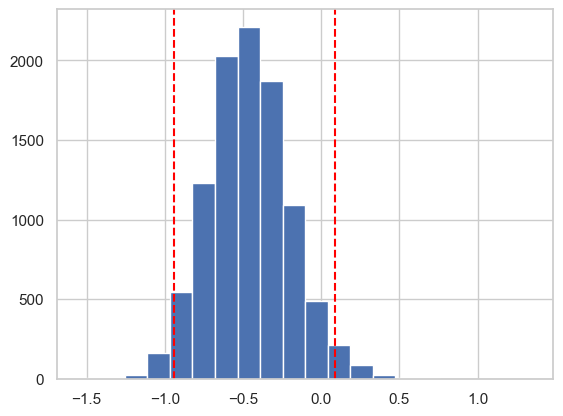

In [59]:
# Bootstrap confidence intervals for the slope
n_bootstraps = 10000
bootstrap_slopes = []
for _ in range(n_bootstraps):
    sample_df = df.sample(n=len(df), replace=True)
    model = smf.ols(f"{acc} ~ {fixed_effect}", data=sample_df).fit()
    # bootstrap_slopes.append(model.params[fixed_effect])
    bootstrap_slopes.append(model.params[fixed_effect])
# Calculate 95% confidence interval
lower_bound = np.percentile(bootstrap_slopes, 2.5)
upper_bound = np.percentile(bootstrap_slopes, 97.5)
print(f"95% Confidence Interval for the slope: [{lower_bound:.4f}, {upper_bound:.4f}]")
plt.hist(bootstrap_slopes, bins=20)
plt.axvline(x=lower_bound, color='red', linestyle='--', label='2.5th Percentile')
plt.axvline(x=upper_bound, color='red', linestyle='--', label='97.5th Percentile')
plt.show()

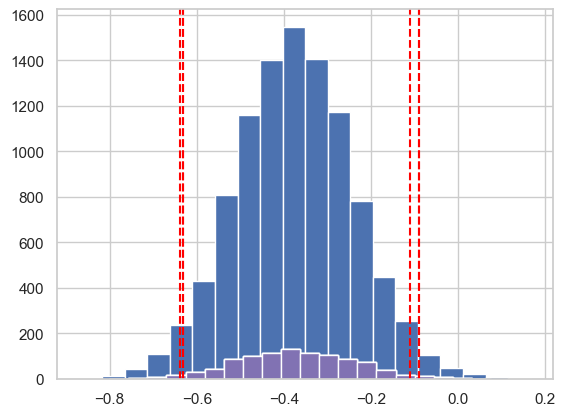

In [121]:
plt.hist(bootstrap_slopes, bins=20)
plt.show()

### PyMC

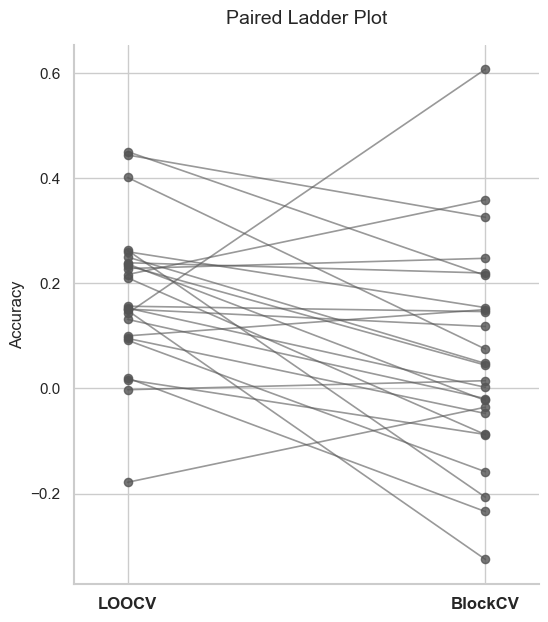

In [528]:
# Identify the two unique values in your condition column
conditions = sorted(df['block_cv'].unique())
cond_left, cond_right = conditions[0], conditions[1]

# Set up the plot framework
fig, ax = plt.subplots(figsize=(6, 7))

# Loop through every unique ID to draw its connecting ladder line
for uid in df['id'].unique():
    # Filter down to the single ID's data points
    id_data = df[df['id'] == uid]
    
    # We need exactly 1 point on the left and 1 point on the right to draw a line
    left_pt = id_data[id_data['block_cv'] == cond_left]
    right_pt = id_data[id_data['block_cv'] == cond_right]
    
    if not left_pt.empty and not right_pt.empty:
        y_left = left_pt['accuracy'].values[0]
        y_right = right_pt['accuracy'].values[0]
        
        # Draw the uniform ladder line
        ax.plot([0, 1], [y_left, y_right], color='#555555', linewidth=1.2, alpha=0.6)
        
        # Add individual scatter dots on the endpoints
        ax.scatter([0, 1], [y_left, y_right], color='#555555', s=35, alpha=0.8)

# Format axes to turn it into a clean slopegraph
ax.set_xticks([0, 1])
ax.set_xticklabels(['LOOCV', 'BlockCV'], fontsize=12, fontweight='bold')
ax.set_xlim(-0.15, 1.15)  # Add breathing room on the margins

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Paired Ladder Plot', fontsize=14, pad=15)

# Clean up graph borders for a minimalist aesthetic
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

plt.show()

The plot looks similar to the Radon in Minnesota (Floor vs Basement) case study, both distribution contain outliers, so the likelihood will be modeled as a Student T's Distribution <br>
No pooling would just draw lines between Block and LOO CV <br>
Complete pooling would ignore individual differences <br>
So we need to introduce some amount of correlation between individuals

##### PyMC analysis for target emotion

Using target emotion as the label for classification yields data for all 3 conditions. <br>

In [96]:
conditions = pd.Categorical(df['condition'])
condition_code_vector = conditions.codes

conditions.categories

Index(['imageonly'], dtype='object')

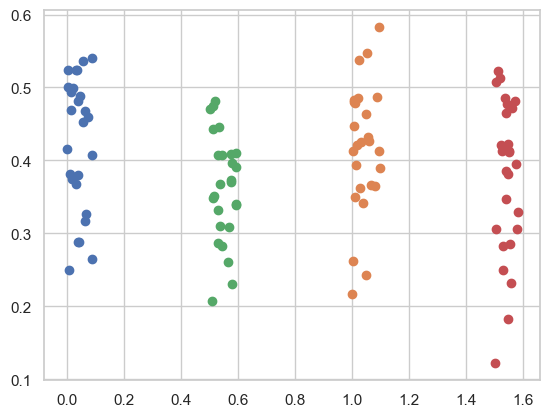

In [79]:
for j in range(2):
    mask = df['block_cv'] == j
    block_df = df[mask]

    step = 0.5 if j == 1 else 0

    for i in range(2):

        mask = block_df['condition'] == conditions.categories[i]
        cond_df = block_df[mask]

        x = np.random.uniform(i+step, i+step+0.1, cond_df.__len__())
        plt.scatter(x, cond_df['accuracy'])

plt.show()

The step due to blockcv is similar across conditions. Due to the restricted dataset and the lack of importance of this parameter for the study, I will ignore the group distinctions and treat it as a pooled parameter <br>
To ensure simplicity, I will assume first there is no differences in accuracy across conditions

##### Linear Regression

In [ ]:
consider_condition = False

conditions = pd.Categorical(df['condition'])
ids = pd.Categorical(df['id'])
# blockcv_codes_vector = df['block_cv'].astype(int).values

### TAS subscale
difs = df.groupby('id')['eot'].first().reindex(ids.categories).values

### Accuracy Observed
accuracy_observed = df['accuracy'].values

with pm.Model() as target_emotion_model:
    σ = pm.InverseGamma("σ", 1, 0.5)
    ν = pm.HalfNormal("ν", 20) 

    β_eot = pm.Normal("β_eot", mu=0, sigma=1)  
    β_0 = pm.Normal("β_0", mu=0, sigma=1)

    accuracy = pm.StudentT("accuracy", mu=β_0 + β_eot*difs, sigma=σ, nu=ν, observed=accuracy_observed)

    prior_idata = pm.sample_prior_predictive(samples=1000, random_seed=42)
    trace_accuracy = pm.sample(target_accept=.9, return_inferencedata=True)


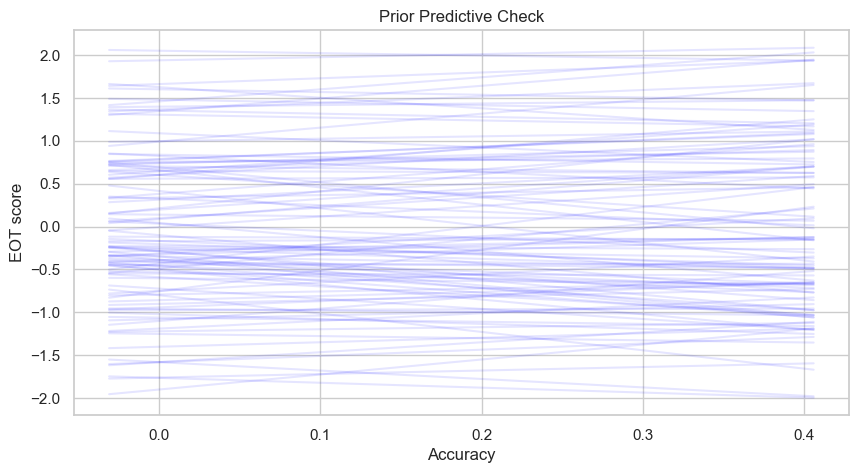

In [409]:
# Extract the prior samples
priors = prior_idata.prior

# Set up the plot
plt.figure(figsize=(10, 5))

x_data = np.linspace(df['eot'].min(), df['eot'].max(), 100)

for i in range(100):
    simulated_intercept = priors["β_0"].values[0][i]
    simulated_slope = priors["β_eot"].values[0][i]
    
    simulated_line = simulated_intercept + (simulated_slope * x_data)
    
    plt.plot(x_data, simulated_line, color="blue", alpha=0.1)

plt.title("Prior Predictive Check")
plt.xlabel("Accuracy")
plt.ylabel("EOT score")
plt.show()

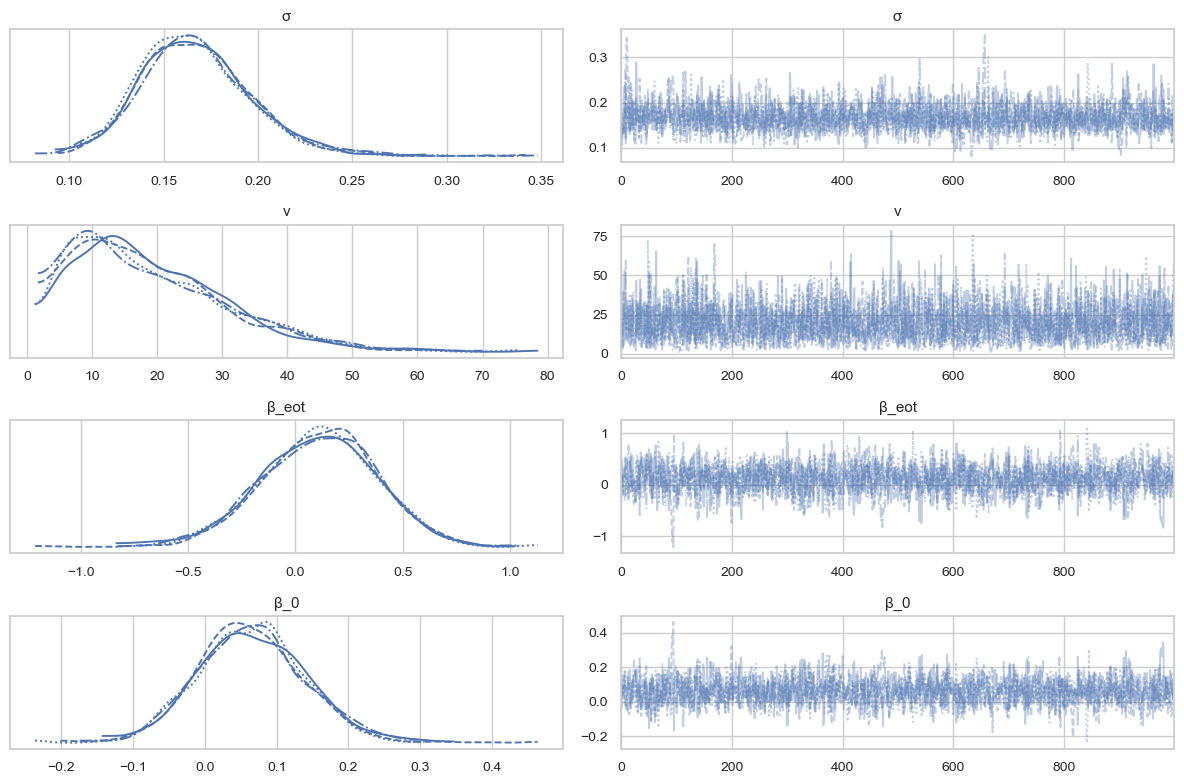

In [405]:
az.plot_trace(trace_accuracy, var_names=[
    'σ', 
    'ν',
    'β_eot',
    'β_0'
])
plt.tight_layout()
plt.show()

In [ ]:
beta_dif_samples = trace_accuracy.posterior["β_eot"].values

prob_negative = np.mean(beta_dif_samples > 0)

print(f"Probability of β_eot being negative: {prob_negative:.2%}")

Probability of β_eot being negative: 66.85%


$\beta_0$ ~ Normal(0, 1) <br>
$\beta_{\text{EOT}}$ ~ Normal(0, 1) <br>
$\nu$ ~ HalfNormal(20) <br>
$\sigma$ ~ InverseGamma(1, 0.5) <br>
accuracy ~ StudentT($\beta_0 + \beta_{\text{EOT}} \times \text{EOT}$, $\sigma$, $\nu$) <br>
<br>
$P(\beta_{\text{EOT}} > 0 \ | \ Y) = 66.85$

Sampling: [accuracy]


c:\Users\Mario Tokumori\.conda\envs\handeln2025\lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

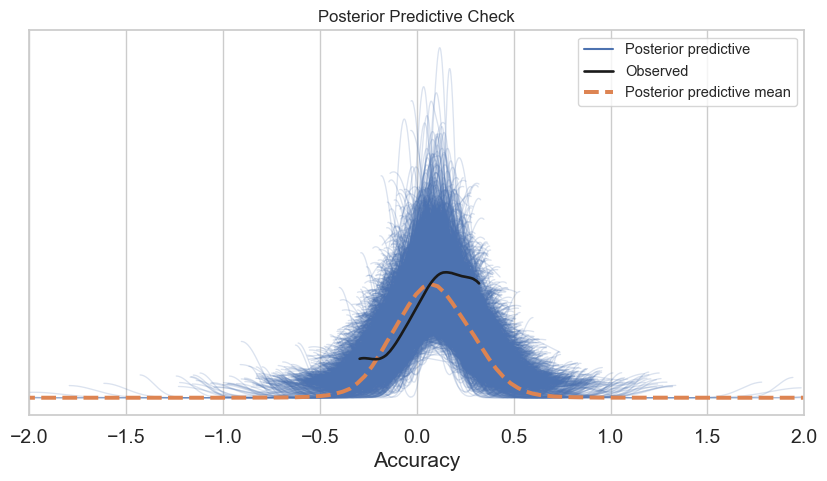

In [410]:
# 1. Generate posterior predictive samples using your original model context
with target_emotion_model:
    ppc = pm.sample_posterior_predictive(trace_accuracy)

az.plot_ppc(ppc, data_pairs={"Accuracy": "accuracy"}, figsize=(10, 5))
plt.title("Posterior Predictive Check")
plt.xlim(-2, 2)
plt.xlabel("Accuracy")
plt.show()

In [680]:
posterior_summary = az.summary(trace_accuracy, var_names=['β_dif', 'β_blockcv', 'σ', 'ν', 'μ_u', 'σ_u'], round_to=3)

# Copies the table to your clipboard
posterior_summary.to_clipboard()

In [681]:
posterior_summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
β_dif,-0.294,0.174,-0.630,0.022,0.003,0.002,2760.879,2751.232,1.000
β_blockcv,-0.127,0.044,-0.207,-0.043,0.001,0.001,4387.987,3121.551,1.002
σ,0.138,0.024,0.091,0.181,0.001,0.000,1530.042,1927.679,1.001
ν,15.179,10.783,1.648,35.259,0.175,0.186,3255.568,2431.060,1.000
μ_u,0.222,0.043,0.143,0.306,0.001,0.001,2469.029,2609.584,1.001
σ_u,0.077,0.039,0.003,0.139,0.001,0.001,900.073,1381.090,1.003


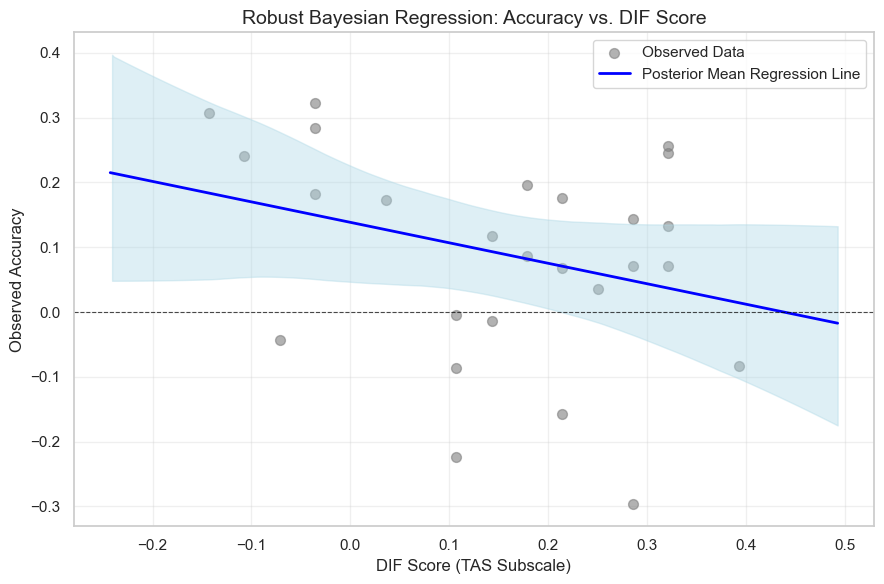

In [329]:
plt.figure(figsize=(9, 6))

# 1. Scatter the original raw data
plt.scatter(difs, accuracy_observed, color='gray', alpha=0.6, label='Observed Data', s=50)

# 2. Extract the posterior samples for the intercept and slope
posterior = trace_accuracy.posterior
b0_samples = posterior['β_0'].values.flatten()
bdif_samples = posterior['β_dif'].values.flatten()

# 3. Create a smooth range of x-values (DIF scores) to draw the line across
x_vals = np.linspace(difs.min() - 0.1, difs.max() + 0.1, 100)

# 4. Calculate the expected mean (mu) for every posterior sample at every x-value
# This uses numpy broadcasting to create a matrix of all possible regression lines
mu_pred = b0_samples[:, None] + bdif_samples[:, None] * x_vals

# 5. Plot the average of all those lines (The Posterior Mean)
mu_mean = mu_pred.mean(axis=0)
plt.plot(x_vals, mu_mean, color='blue', label='Posterior Mean Regression Line', linewidth=2)

# 6. Plot the 94% HDI (Highest Density Interval) around the mean
az.plot_hdi(x_vals, mu_pred, color='lightblue', fill_kwargs={'alpha': 0.4})
# (Note: ArviZ automatically adds '94% HDI' to the legend)

# Formatting
plt.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7) # Chance line
plt.title('Robust Bayesian Regression: Accuracy vs. DIF Score', fontsize=14)
plt.xlabel('DIF Score (TAS Subscale)', fontsize=12)
plt.ylabel('Observed Accuracy', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

#####

In [666]:
consider_condition = False

conditions = pd.Categorical(df['condition'])
ids = pd.Categorical(df['id'])
# blockcv_codes_vector = df['block_cv'].astype(int).values

### TAS subscale
difs = df.groupby('id')['dif'].first().reindex(ids.categories).values

### Accuracy Observed
accuracy_observed = df['accuracy'].values

with pm.Model() as target_emotion_model:
    # Likelihood's params
    σ = pm.InverseGamma("σ", 1, 0.5) # standard deviation of the likelihood
    # Reasons for this choice: I know sigma is not 0, but I don't know how much it is
    ν = pm.HalfNormal("ν", 20) # degrees of freedom for Student's t-distribution
    # Same here but I don't know if this is 0, but I know it cannot be negative

    # Between-subject differences partially pooled
    μ_u = pm.Normal("μ_u", mu=0, sigma=1) 
    σ_u = pm.HalfNormal("σ_u", 1)
    u_raw = pm.Normal("u_raw", mu=0, sigma=1, shape=len(ids.categories))
    β_dif = pm.Normal("β_dif", mu=0, sigma=1)
    u = pm.Deterministic("u", μ_u + σ_u * u_raw + β_dif * difs)
    
    accuracy = pm.StudentT("accuracy", mu=u[ids.codes], sigma=σ, nu=ν, observed=accuracy_observed)
    
    trace_accuracy = pm.sample(target_accept=.9, return_inferencedata=True)


c:\Users\Mario Tokumori\.conda\envs\handeln2025\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [σ, ν, μ_u, σ_u, u_raw, β_dif]


c:\Users\Mario Tokumori\.conda\envs\handeln2025\lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 72 seconds.


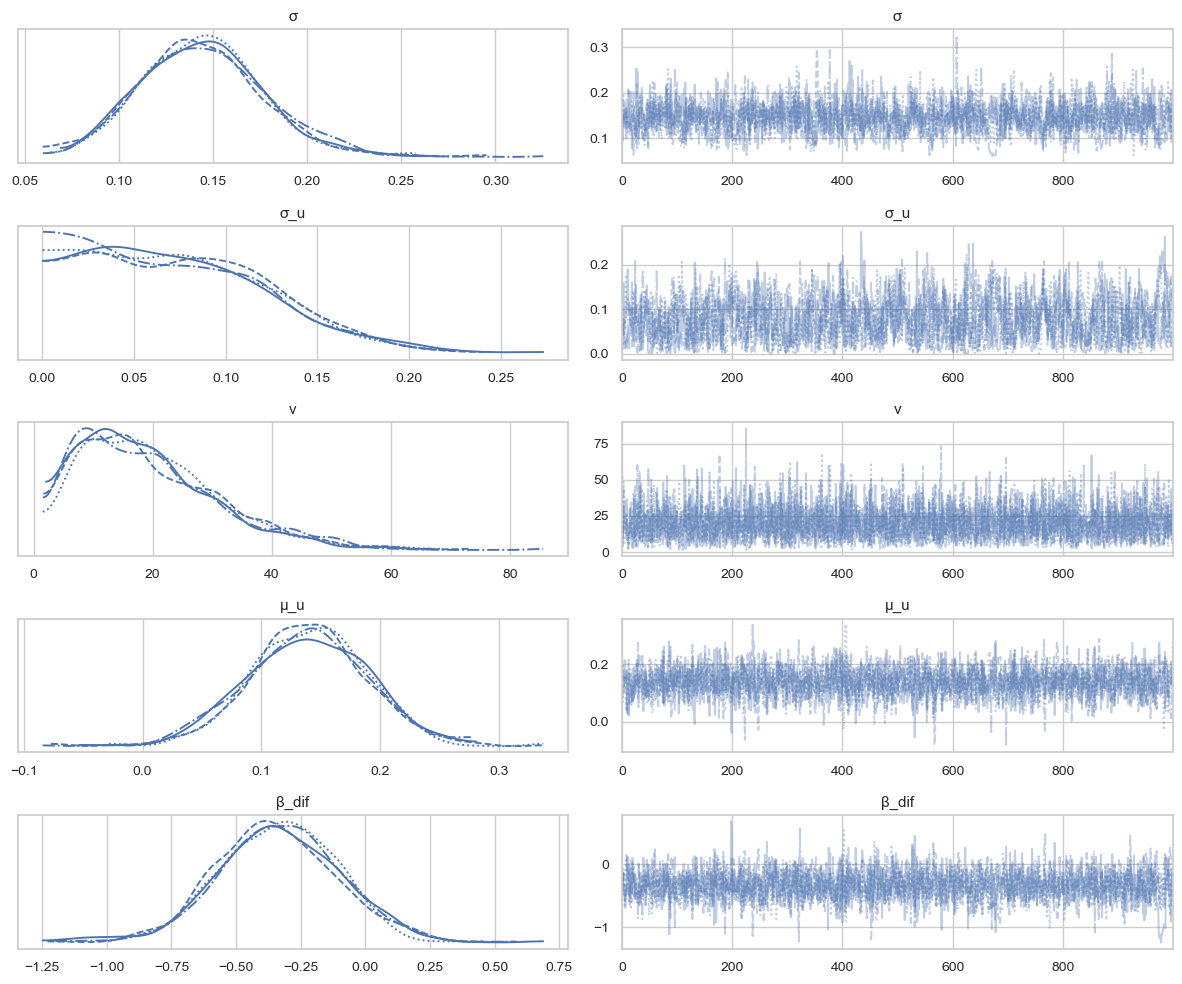

In [213]:
az.plot_trace(trace_accuracy, var_names=[
    'σ', # Scale / Within subjects variance
    'σ_u', # Between subjects variance
    'ν',
    'μ_u',
    'β_dif',
])
plt.tight_layout()
plt.show()

In [24]:
df['accuracy'] = df['block_bal_acc']

In [673]:
consider_condition = False
conditions_codes_vector = pd.Categorical(df['condition']).codes
ids = pd.Categorical(df['id'])
blockcv_codes_vector = df['block_cv'].astype(int).values

### TAS subscale
difs = df.groupby('id')['dif'].first().reindex(ids.categories).values
### Accuracy Observed
accuracy_observed = df['accuracy'].values

with pm.Model() as target_emotion_model:
    # Likelihood's params
    σ = pm.InverseGamma("σ", 1, 0.5) # standard deviation of the likelihood
    # Reasons for this choice: I know sigma is not 0, but I don't know how much it is
    ν = pm.HalfNormal("ν", 20) # degrees of freedom for Student's t-distribution
    # Same here but I don't know if this is 0, but I know it cannot be negative

    # Beta coefficients
    β_blockcv = pm.Normal("β_blockcv", mu=0, sigma=1) 
    if consider_condition:
        β_condition = pm.Normal("β_condition", mu=0, sigma=1)

    # Between-subject differences partially pooled
    μ_u = pm.Normal("μ_u", mu=0, sigma=1) 
    σ_u = pm.HalfNormal("σ_u", 1)
    β_dif = pm.Normal("β_dif", mu=0, sigma=1)  
    u_raw = pm.Normal("u_raw", mu=0, sigma=1, shape=len(ids.categories))
    u = pm.Deterministic("u", μ_u + σ_u * u_raw + β_dif * difs)

    if consider_condition:
        μ = pm.Deterministic("μ", β_condition * conditions_codes_vector + u[ids.codes] + β_blockcv * blockcv_codes_vector)
    else:
        μ = pm.Deterministic("μ", u[ids.codes] + β_blockcv * blockcv_codes_vector)

    accuracy = pm.StudentT("accuracy", mu=μ, sigma=σ, nu=ν, observed=accuracy_observed)
    
    trace_accuracy = pm.sample(target_accept=.9, return_inferencedata=True)


c:\Users\Mario Tokumori\.conda\envs\handeln2025\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [σ, ν, β_blockcv, μ_u, σ_u, β_dif, u_raw]


c:\Users\Mario Tokumori\.conda\envs\handeln2025\lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 56 seconds.


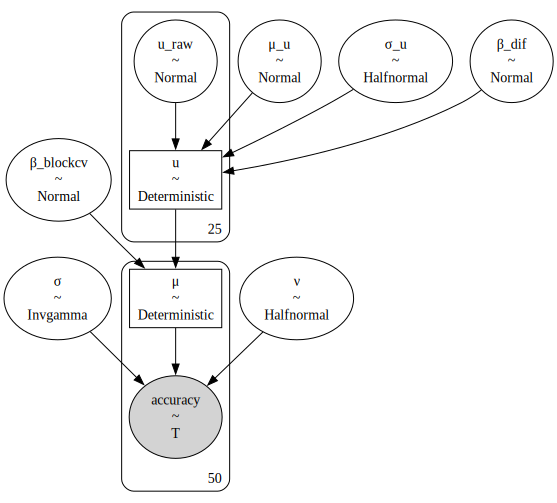

In [669]:
pm.model_to_graphviz(target_emotion_model)

$\beta_0$ ~ Normal(0, 1) <br>
$\beta_{\text{DIF}}$ ~ Normal(0, 1) <br>
$\nu$ ~ HalfNormal(20) <br>
$\sigma$ ~ InverseGamma(1, 0.5) <br>
accuracy ~ StudentT($\beta_0 + \beta_{\text{DIF}} \times \text{DIF}$, $\sigma$, $\nu$) <br>
<br>
$P(\beta_{\text{DIF}} < 0 \ | \ Y) = 95.28$



$\sigma_u$ ~ HalfNormal(1) <br>
$\mu_u$ ~ Normal(0, 1) <br>
$\beta_{dif}$ ~ Normal(0, 1) <br>
<br>
$u_j$ ~ Normal($\mu_u + \beta_{dif}$, $\sigma_u$) <br>
<br>
$\nu$ ~ HalfNormal(20) <br>
$\sigma$ ~ InverseGamma(1, 0.5) <br>
accuracy ~ StudentT($u_j$, $\sigma$, $\nu$)

$\sigma_u$ ~ HalfNormal(1) <br>
$\mu_u$ ~ Normal(0, 1) <br>
$\beta_{dif}$ ~ Normal(0, 1) <br>
<br>
$u_j$ ~ Normal($\mu_u + \beta_{dif}$, $\sigma_u$) <br>
$\beta_{block}$ ~ Normal(0, 1) <br>
<br>
$\nu$ ~ HalfNormal(20) <br>
$\sigma$ ~ InverseGamma(1, 0.5) <br>
accuracy ~ StudentT($u_j + \beta_{block}$, $\sigma$, $\nu$)

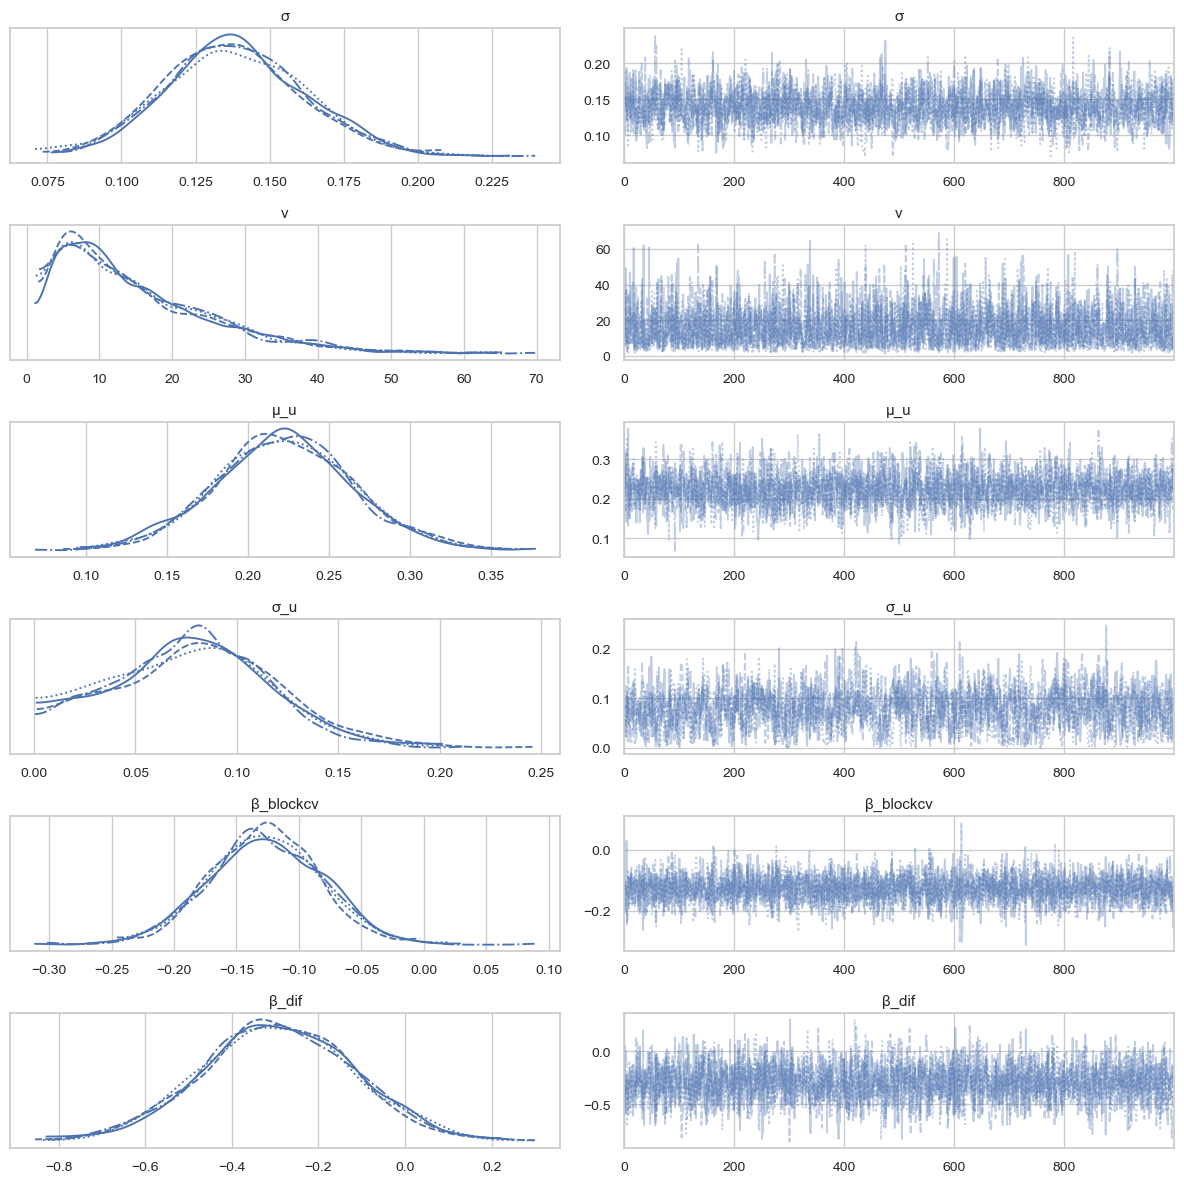

In [674]:
# Define variables to plot based on your boolean flag
# var_names = ["σ", "ν", "μ_u", "σ_u", "β_dif"]
var_names = ["σ", "ν", "μ_u", "σ_u", "β_blockcv", "β_dif"]
# var_names = ["σ", "ν", "β_condition", "μ_u", "σ_u", "β_eot"]

# var_names = ["σ", "ν", "μ_u", "σ_u", "β_dif"]
if consider_condition:
    var_names.append("β_condition")

# Generate trace plot
az.plot_trace(trace_accuracy, var_names=var_names, compact=True)
plt.tight_layout()
plt.show()

In [675]:
beta_dif_samples = trace_accuracy.posterior["β_dif"].values

prob_negative = np.mean(beta_dif_samples < 0)

print(f"Probability of β_dif being negative: {prob_negative:.2%}")

Probability of β_dif being negative: 95.28%


In [ ]:
if consider_condition == False:        
    az.plot_trace(trace_accuracy, var_names=[
        'sigma', # Scale / Within subjects variance
        'sigma_u', # Between subjects variance
        'nu',
        'mu_u',
        # 'beta_blockcv',
        'beta_dif'
    ])
else:
    az.plot_trace(trace_accuracy, var_names=[
        'sigma', # Scale / Within subjects variance
        'sigma_u', # Between subjects variance
        'nu',
        'mu_u',
        'beta_blockcv',
        'beta_dif',
        'beta_condition'
    ])
plt.tight_layout()
plt.show()

In [587]:
difs.argmin()

np.int64(20)

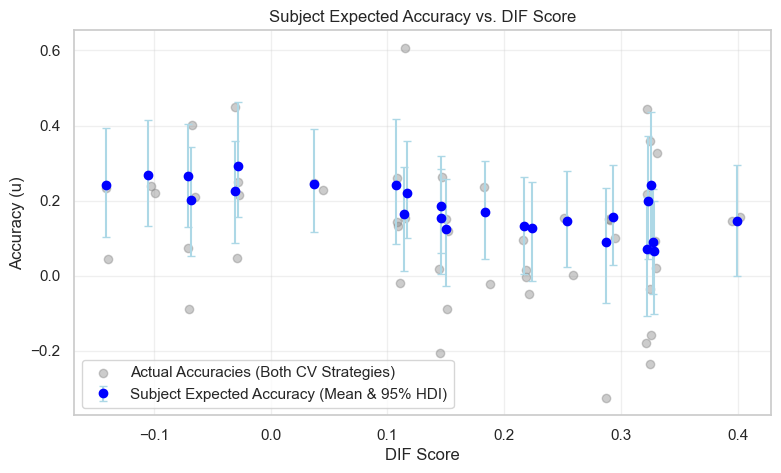

In [688]:
tas_subscale = 'dif'

# Compute the posterior mean and 95% HDI for each subject's baseline expectation 'u'
post_u = trace_accuracy.posterior["u"]
mean_accuracy = post_u.mean(dim=["chain", "draw"]).values
hdi_accuracy = az.hdi(post_u, hdi_prob=0.95)["u"].values

# Calculate symmetric/asymmetric error bars for plt.errorbar
yerr = np.vstack([
    mean_accuracy - hdi_accuracy[:, 0],  # Lower bounds
    hdi_accuracy[:, 1] - mean_accuracy   # Upper bounds
])

plt.figure(figsize=(9, 5))

noise = np.random.uniform(0, 0.01, df[tas_subscale].__len__())
plt.scatter(
    x=df[tas_subscale] + noise, 
    y=df['accuracy'], ## <-- YOUR RAW DATA HERE
    color='gray', 
    alpha=0.4,          # Makes points transparent
    zorder=1,           # Puts it in the background
    label='Actual Accuracies (Both CV Strategies)',
)

noise = np.random.uniform(0, 0.01, difs.__len__())
plt.errorbar(
    x=difs + noise, 
    y=mean_accuracy, 
    yerr=yerr, 
    fmt='o', 
    color='blue', 
    ecolor='lightblue', 
    capsize=3,
    label='Subject Expected Accuracy (Mean & 95% HDI)'
)

plt.xlabel("DIF Score")
plt.ylabel("Accuracy (u)")
plt.title("Subject Expected Accuracy vs. DIF Score")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

ValueError: operands could not be broadcast together with shapes (30,) (52,) 

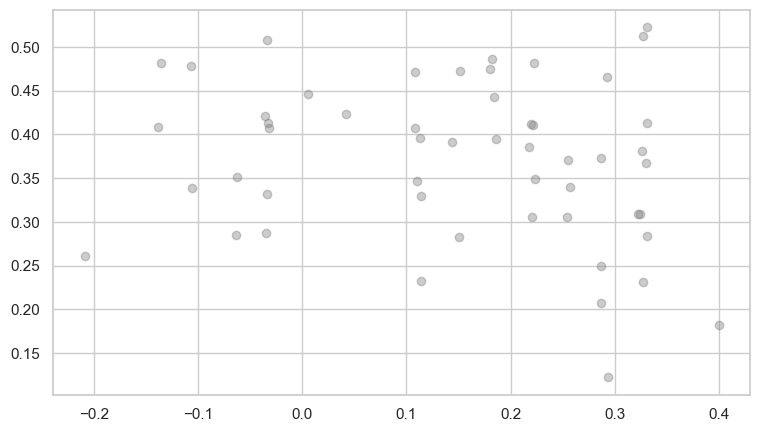

In [35]:
# Compute the posterior mean and 95% HDI for each subject's baseline expectation 'u'
post_u = trace_accuracy.posterior["u"]
mean_accuracy = post_u.mean(dim=["chain", "draw"]).values
hdi_accuracy = az.hdi(post_u, hdi_prob=0.95)["u"].values

# Calculate symmetric/asymmetric error bars for plt.errorbar
yerr = np.vstack([
    mean_accuracy - hdi_accuracy[:, 0],  # Lower bounds
    hdi_accuracy[:, 1] - mean_accuracy   # Upper bounds
])

# Create jitter so overlapping points don't hide each other

plt.figure(figsize=(9, 5))

noise = np.random.uniform(0, 0.01, df['dif'].__len__())
plt.scatter(
    x=df['dif'] + noise, 
    y=df['accuracy'], # <-- YOUR RAW DATA HERE
    color='gray', 
    alpha=0.4,          # Makes points transparent
    zorder=1,           # Puts it in the background
    label='Observed Accuracy (Raw)'
)

# 2. FOREGROUND ERROR BARS (Model Estimates)
plt.errorbar(
    x=difs + noise,     # Using the exact same jitter so points align
    y=mean_accuracy, 
    yerr=yerr, 
    fmt='o', 
    color='blue', 
    ecolor='lightblue', 
    capsize=3,
    zorder=2,           # Puts the error bars on top of the scatter plot
    label='Subject Expected Accuracy (Mean & 95% HDI)'
)

plt.xlabel("DDF Score")
plt.ylabel("Accuracy")
plt.title("Subject Expected Accuracy vs. DDF Score")
plt.grid(True, alpha=0.3, zorder=0) # Grid in the very back
plt.legend()
plt.show()

Sampling: [accuracy]


c:\Users\Mario Tokumori\.conda\envs\handeln2025\lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

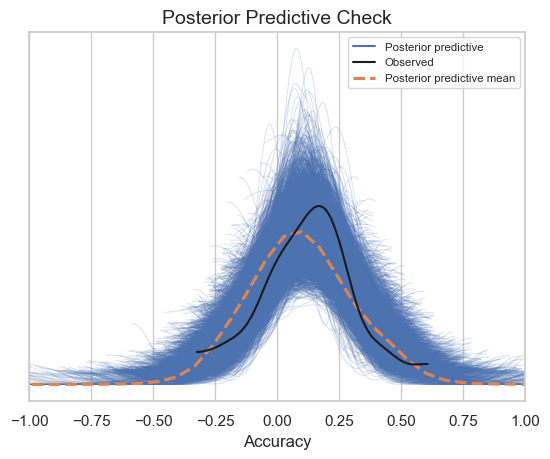

In [686]:
with target_emotion_model:
    # Generate predicted data based on the posterior traces
    pm.sample_posterior_predictive(trace_accuracy, extend_inferencedata=True)
# Plot the real observed accuracy distribution vs. the model's generated predictions
az.plot_ppc(trace_accuracy)
plt.title("Posterior Predictive Check", fontsize=14)
plt.xlabel("Accuracy")
plt.xlim(-1, 1)
plt.show()

### Feature Importance

In [ ]:
from sklearn.model_selection import cross_validate, LeaveOneGroupOut, LeaveOneOut

In [ ]:
result = []
for row_index in range(df.__len__()):
    data_string = df['df'].loc[row_index]
    id = df['id'].loc[row_index]
    condition = df['condition'].loc[row_index]
    data = pd.read_csv(io.StringIO(data_string), sep='\s+')

    if len(data) < 30:
        print(f"Skipping {id} in {condition}: Only {len(data)} rows. Need at least 30.")
        continue

    features = ['VSA', 'HR', 'ComEDA']
    X = data[features]
    y = data['Emotion']
    groups = data['Block'].values

    if len(np.unique(groups)) < 2:
        print(f"Skipping {id} in {condition}: Need at least 2 blocks for LOGO-CV.")
        continue

    ### Emotion response
    # Single scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    logo = LeaveOneOut()
    C = 1.0

    ### Target emotion
    # # Blockwise scaling
    # scaler = StandardScaler()
    # X_scaled = np.zeros_like(X)
    # for block_id in np.unique(groups):
    #     mask = groups == block_id
    #     X_scaled[mask] = scaler.fit_transform(X[mask])

    # logo = LeaveOneGroupOut()
    # C = 0.1


    try: 
        clf = SVC(kernel='linear', C=C, gamma='auto', class_weight='balanced')

        # clf.fit(X_scaled, y)
        cv_results = cross_validate(clf, X_scaled, y, groups=groups, cv=logo, return_estimator=True)
        trained_models_from_folds = cv_results['estimator']
        fold_weights = [model.coef_ for model in trained_models_from_folds]
    except ValueError as e:
        print(f"Skipping {id} due to internal CV error: {e}")
        continue

    # weights = clf.coef_.copy()
    # for i in range(weights.shape[0]): # row indexer
    #     row_abssum = weights[i].__abs__().sum()
    #     for j in range(weights.shape[1]): # column indexer
    #         weights[i][j] = weights[i][j].__abs__() / row_abssum

    # assert np.isclose(weights.sum(), weights.shape[0])
    # # mean_weights = weights.sum(axis=0)
    # # mean_weights = mean_weights / 3
    # mean_weights = weights.mean(axis=0)

    result.append(pd.DataFrame({
        'id': id,
        'condition': condition,
        'fold_weights': fold_weights,
        'Feature': str(X.columns),
        # 'Importance': mean_weights
    }))

Skipping 1 in image-only: Only 24 rows. Need at least 30.
Skipping 1 in audio-only: Only 20 rows. Need at least 30.
Skipping 2 in image-only: Only 18 rows. Need at least 30.


c:\Users\Mario Tokumori\.conda\envs\handeln2025\lib\site-packages\sklearn\model_selection\_split.py:86: UserWarning: The groups parameter is ignored by LeaveOneOut
  warnings.warn(
c:\Users\Mario Tokumori\.conda\envs\handeln2025\lib\site-packages\sklearn\model_selection\_split.py:86: UserWarning: The groups parameter is ignored by LeaveOneOut
  warnings.warn(


Skipping 2 in audio-only: Only 10 rows. Need at least 30.
Skipping 3 in image-only: Only 24 rows. Need at least 30.
Skipping 3 in audio+image: Only 7 rows. Need at least 30.
Skipping 3 in audio-only: Only 6 rows. Need at least 30.


c:\Users\Mario Tokumori\.conda\envs\handeln2025\lib\site-packages\sklearn\model_selection\_split.py:86: UserWarning: The groups parameter is ignored by LeaveOneOut
  warnings.warn(
c:\Users\Mario Tokumori\.conda\envs\handeln2025\lib\site-packages\sklearn\model_selection\_split.py:86: UserWarning: The groups parameter is ignored by LeaveOneOut
  warnings.warn(
c:\Users\Mario Tokumori\.conda\envs\handeln2025\lib\site-packages\sklearn\model_selection\_split.py:86: UserWarning: The groups parameter is ignored by LeaveOneOut
  warnings.warn(
c:\Users\Mario Tokumori\.conda\envs\handeln2025\lib\site-packages\sklearn\model_selection\_split.py:86: UserWarning: The groups parameter is ignored by LeaveOneOut
  warnings.warn(
c:\Users\Mario Tokumori\.conda\envs\handeln2025\lib\site-packages\sklearn\model_selection\_split.py:86: UserWarning: The groups parameter is ignored by LeaveOneOut
  warnings.warn(
c:\Users\Mario Tokumori\.conda\envs\handeln2025\lib\site-packages\sklearn\model_selection\_spli

Skipping 6 in audio-only: Only 22 rows. Need at least 30.


...

c:\Users\Mario Tokumori\.conda\envs\handeln2025\lib\site-packages\sklearn\model_selection\_split.py:86: UserWarning: The groups parameter is ignored by LeaveOneOut
  warnings.warn(
c:\Users\Mario Tokumori\.conda\envs\handeln2025\lib\site-packages\sklearn\model_selection\_split.py:86: UserWarning: The groups parameter is ignored by LeaveOneOut
  warnings.warn(


Skipping 40 in audio-only: Only 26 rows. Need at least 30.
Skipping 41 in image-only: Only 19 rows. Need at least 30.
Skipping 41 in audio+image: Only 19 rows. Need at least 30.
Skipping 41 in audio-only: Only 6 rows. Need at least 30.
Skipping 42 in audio+image: Only 23 rows. Need at least 30.
Skipping 42 in audio-only: Only 6 rows. Need at least 30.
Skipping 43 in image-only: Only 29 rows. Need at least 30.
Skipping 43 in audio+image: Only 29 rows. Need at least 30.
Skipping 43 in audio-only: Only 24 rows. Need at least 30.


c:\Users\Mario Tokumori\.conda\envs\handeln2025\lib\site-packages\sklearn\model_selection\_split.py:86: UserWarning: The groups parameter is ignored by LeaveOneOut
  warnings.warn(
c:\Users\Mario Tokumori\.conda\envs\handeln2025\lib\site-packages\sklearn\model_selection\_split.py:86: UserWarning: The groups parameter is ignored by LeaveOneOut
  warnings.warn(


Skipping 44 in audio-only: Only 11 rows. Need at least 30.


c:\Users\Mario Tokumori\.conda\envs\handeln2025\lib\site-packages\sklearn\model_selection\_split.py:86: UserWarning: The groups parameter is ignored by LeaveOneOut
  warnings.warn(


In [ ]:
# Each row corresponds to a set of classifiers (OneVSOne multiclass)
# corresponding to an id, a condition, and a block
result_df = pd.concat(result)

result = []
for row in range(result_df.__len__()):
    weights = result_df.iloc[row]['fold_weights']
    row_abssums = np.abs(weights).sum(axis=1, keepdims=True)
    proportional_weights = np.abs(weights) / row_abssums

    for i in range(result_df.iloc[row]['fold_weights'].shape[0]): # iterate over each binary classifiers
            result.append(pd.DataFrame({
                'id': result_df.iloc[row]['id'],
                'condition': result_df.iloc[row]['condition'],
                # 'Feature': result_df.iloc[row]['Feature'],
                'Feature': ['VSA', 'HR', 'ComEDA'],
                'Importance': proportional_weights[i]
            }))



# assert np.isclose(weights.sum(), weights.shape[0])
# # mean_weights = weights.sum(axis=0)
# # mean_weights = mean_weights / 3

# mean_weights = weights.mean(axis=0)

In [ ]:
result_df = pd.concat(result)
result_df.head()

,id,condition,Feature,Importance
0,1,audio+image,VSA,0.204983
1,1,audio+image,HR,0.247135
2,1,audio+image,ComEDA,0.547882
0,1,audio+image,VSA,0.309712
1,1,audio+image,HR,0.221845


In [ ]:
for id in result_df['id'].unique():
    p = Participant(id)

    result_df.loc[result_df['id'] == id, 'tas'] = p.tas_corrected    
    result_df.loc[result_df['id'] == id, 'eot'] = p.eot_corrected
    result_df.loc[result_df['id'] == id, 'ddf'] = p.ddf_corrected
    result_df.loc[result_df['id'] == id, 'dif'] = p.dif_corrected

In [ ]:
result_df

,id,condition,Feature,Importance,tas,eot,ddf,dif
0,1,audio+image,VSA,0.035785,70.0,33.0,17.0,20.0
1,1,audio+image,HR,0.093763,70.0,33.0,17.0,20.0
2,1,audio+image,ComEDA,0.870453,70.0,33.0,17.0,20.0
0,1,audio+image,VSA,0.058125,70.0,33.0,17.0,20.0
1,1,audio+image,HR,0.156205,70.0,33.0,17.0,20.0
...,...,...,...,...,...,...,...,...
1,44,audio+image,HR,0.634922,81.0,35.0,21.0,25.0
2,44,audio+image,ComEDA,0.189769,81.0,35.0,21.0,25.0
0,44,audio+image,VSA,0.083494,81.0,35.0,21.0,25.0
1,44,audio+image,HR,0.542523,81.0,35.0,21.0,25.0


In [ ]:
result_df = result_df[result_df['condition'] == 'image-only']

In [ ]:
result_df['df'] = result_df['dif'] + result_df['ddf']

C:\Users\Mario Tokumori\AppData\Local\Temp\ipykernel_23444\260897603.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_df['df'] = result_df['dif'] + result_df['ddf']


In [ ]:
result_df.head()

,id,condition,Feature,Importance,tas,eot,ddf,dif
0,4,image-only,VSA,0.654051,55.0,26.0,10.0,19.0
1,4,image-only,HR,0.104093,55.0,26.0,10.0,19.0
2,4,image-only,ComEDA,0.241855,55.0,26.0,10.0,19.0
0,4,image-only,VSA,0.636881,55.0,26.0,10.0,19.0
1,4,image-only,HR,0.089085,55.0,26.0,10.0,19.0


In [ ]:
result_df['tas'] = (result_df['tas'] - 20)/(100 - 20)
# 8 items with 5-point Likert scale, so max score is 40
result_df['eot'] = (result_df['eot'] - 8)/(40 - 8)
# 5 items
result_df['ddf'] = (result_df['ddf'] - 5)/(25 - 5)
# 7 items
result_df['dif'] = (result_df['dif'] - 7)/(35 - 7)

result_df['dif'] = result_df['dif'] - 1/2


In [ ]:
result_df

,id,condition,Feature,Importance,tas,eot,ddf,dif
0,4,image-only,VSA,0.654051,0.4375,0.56250,0.25,-0.071429
1,4,image-only,HR,0.104093,0.4375,0.56250,0.25,-0.071429
2,4,image-only,ComEDA,0.241855,0.4375,0.56250,0.25,-0.071429
0,4,image-only,VSA,0.636881,0.4375,0.56250,0.25,-0.071429
1,4,image-only,HR,0.089085,0.4375,0.56250,0.25,-0.071429
...,...,...,...,...,...,...,...,...
1,44,image-only,HR,0.752247,0.7625,0.84375,0.80,0.142857
2,44,image-only,ComEDA,0.080789,0.7625,0.84375,0.80,0.142857
0,44,image-only,VSA,0.444314,0.7625,0.84375,0.80,0.142857
1,44,image-only,HR,0.364479,0.7625,0.84375,0.80,0.142857


In [ ]:
mean_importance_df = result_df.groupby(['id', 'Feature'])['Importance'].mean().reset_index()

In [ ]:
mean_importance_df

,id,Feature,Importance,dif
0,4,ComEDA,0.393066,-0.071429
1,4,HR,0.233993,-0.071429
2,4,VSA,0.372942,-0.071429
3,6,ComEDA,0.332405,0.321429
4,6,HR,0.418726,0.321429
...,...,...,...,...
70,42,HR,0.438398,0.250000
71,42,VSA,0.359315,0.250000
72,44,ComEDA,0.161390,0.142857
73,44,HR,0.616525,0.142857


In [ ]:
dif_mapping = result_df.drop_duplicates(subset=['id']).set_index('id')['dif']
mean_importance_df['dif'] = mean_importance_df['id'].map(dif_mapping)

                            OLS Regression Results                            
Dep. Variable:             Importance   R-squared:                       0.079
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     1.967
Date:                Mon, 08 Jun 2026   Prob (F-statistic):              0.174
Time:                        11:49:33   Log-Likelihood:                 11.564
No. Observations:                  25   AIC:                            -19.13
Df Residuals:                      23   BIC:                            -16.69
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.3745      0.044      8.466      0.0

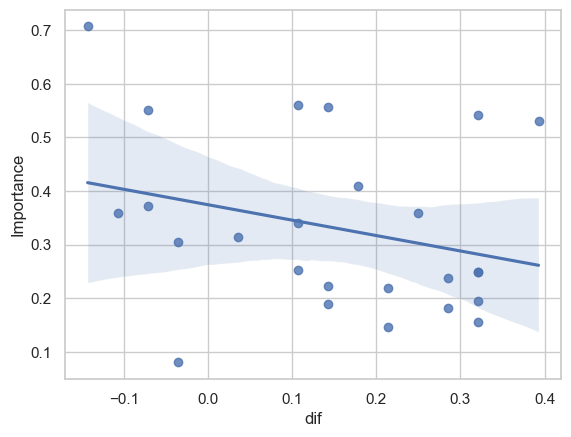

In [ ]:
feature = 'VSA'
effect = 'dif'

current_df = mean_importance_df[mean_importance_df['Feature'] == feature].copy()

model = smf.ols(f"Importance ~ {effect}", data=current_df).fit()

sns.regplot(data=current_df, x=effect, y='Importance')

print(model.summary())

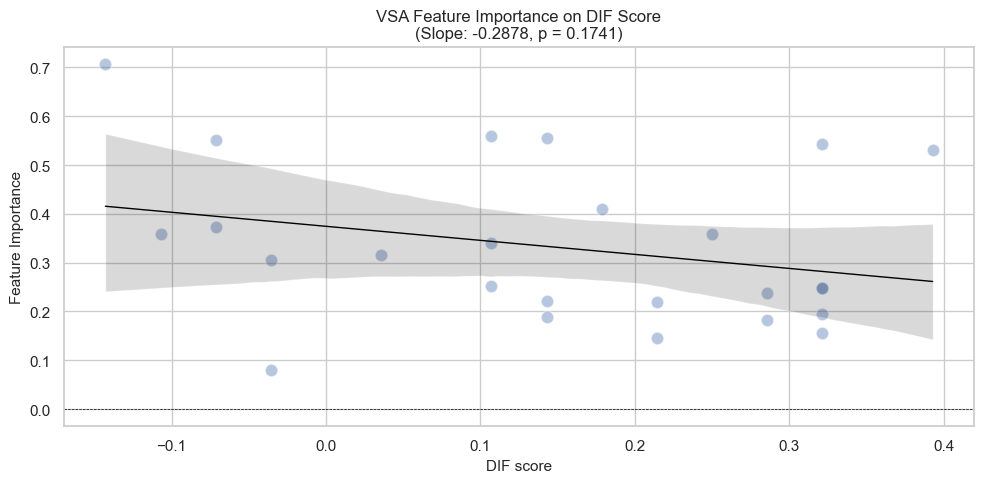

In [ ]:
# 1. Set the aesthetic style
sns.set_theme(style="whitegrid")

# 2. Create the figure
plt.figure(figsize=(10, 5))

# 3. Plot the data points and the regression line
# Seaborn's regplot will automatically calculate the best fit line 
# and a 95% confidence interval shadow.
sns.regplot(
    x=effect, 
    y='Importance', 
    data=current_df, 
    scatter_kws={'alpha':0.4, 's':80, 'edgecolor':'white'},
    line_kws={'color':'black', 'lw':1}
)

chance_level = 0
plt.axhline(y=chance_level, color='black', linestyle='--', lw=0.5, label=f'Chance ({chance_level})')

# 4. Add labels and title using the coefficients from your summary
intercept = model.params['Intercept']
slope = model.params[effect]
p_value = model.pvalues[effect]

plt.title(f'VSA Feature Importance on {effect.upper()} Score\n'
          f'(Slope: {slope:.4f}, p = {p_value:.4f})', fontsize=12)
# plt.title(f'Audio+Image Condition: Ordinary Least Squares Regression of Leave-One-Block-Out CV balanced accuracy vs TAS score\n(Slope: {slope:.4f}, p = {p_value:.4f})', fontsize=14)
plt.xlabel(f'{effect.upper()} score', fontsize=11)
plt.ylabel('Feature Importance', fontsize=11)

# 5. Optional: Set Y-axis limits if dealing with accuracy (0 to 1)
# plt.ylim(0, 0.6)
# plt.xlim(0., 0.9)

plt.tight_layout()
plt.show()

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: importance_100
No. Observations: 2686    Method:             REML          
No. Groups:       25      Scale:              303.0454      
Min. group size:  30      Log-Likelihood:     -11534.1449   
Max. group size:  171     Converged:          Yes           
Mean group size:  107.4                                     
-------------------------------------------------------------
              Coef.   Std.Err.    z    P>|z|   [0.025  0.975]
-------------------------------------------------------------
Intercept     28.651     4.679  6.124  0.000   19.481  37.820
dif           15.105    21.696  0.696  0.486  -27.418  57.628
Group Var    278.058     4.828                               



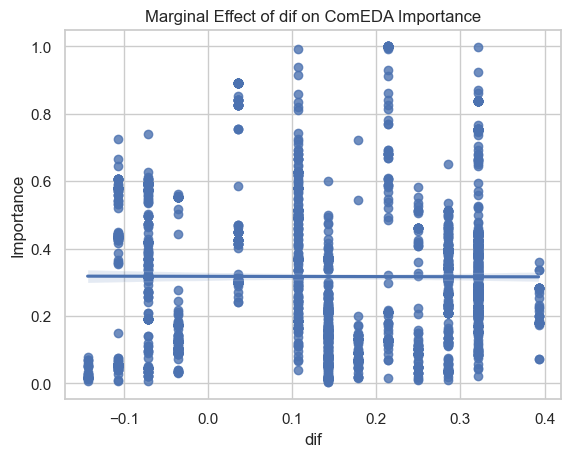

In [ ]:
feature = 'ComEDA'
effect = 'dif'

df_comeda = result_df[result_df['Feature'] == feature].copy()
df_comeda['importance_100'] = df_comeda['Importance'] * 100

model = smf.mixedlm(f"importance_100 ~ {effect}", data=df_comeda, groups=df_comeda['id']).fit()

print(model.summary())

sns.regplot(data=df_comeda, x=effect, y='Importance')
plt.title(f"Marginal Effect of {effect} on {feature} Importance")
plt.show()

In [ ]:
result_df.head()

,id,condition,Feature,Importance,tas,eot,ddf,dif
0,4,image-only,VSA,0.654051,0.4375,0.5625,0.25,-0.071429
1,4,image-only,HR,0.104093,0.4375,0.5625,0.25,-0.071429
2,4,image-only,ComEDA,0.241855,0.4375,0.5625,0.25,-0.071429
0,4,image-only,VSA,0.636881,0.4375,0.5625,0.25,-0.071429
1,4,image-only,HR,0.089085,0.4375,0.5625,0.25,-0.071429


In [ ]:
vsa_df = result_df[result_df['Feature'] == 'VSA']
hr_df = result_df[result_df['Feature'] == 'HR']
comeda_df = result_df[result_df['Feature'] == 'ComEDA']

In [ ]:
import scipy.special

In [ ]:
current_df = vsa_df

conditions = pd.Categorical(current_df['condition'])
ids = pd.Categorical(current_df['id'])
# blockcv_codes_vector = current_df['block_cv'].astype(int).values
difs = current_df.groupby('id')['dif'].first().reindex(ids.categories).values

importance_observed = current_df['Importance'].values

with pm.Model() as importance_model:
    # Likelihood's params
    σ = pm.InverseGamma("σ", 1, 0.5) # standard deviation of the likelihood
    # Reasons for this choice: I know sigma is not 0, but I don't know how much it is
    ν = pm.HalfNormal("ν", 20) # degrees of freedom for Student's t-distribution
    # Same here but I don't know if this is 0, but I know it cannot be negative

    # Between-subject differences partially pooled
    μ_u = pm.Normal("μ_u", mu=0, sigma=1)
    σ_u = pm.HalfNormal("σ_u", 1)
    u_raw = pm.Normal("u_raw", mu=0, sigma=1, shape=len(ids.categories))
    β_dif = pm.Normal("β_dif", mu=0, sigma=1)
    u = pm.Deterministic("u", μ_u + σ_u * u_raw + β_dif * difs)

    importance = pm.StudentT("Importance", mu=u[ids.codes], sigma=σ, nu=ν, observed=importance_observed)
    
    trace_accuracy = pm.sample(target_accept=.9, return_inferencedata=True)


c:\Users\Mario Tokumori\.conda\envs\handeln2025\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [σ, ν, μ_u, σ_u, u_raw, β_dif]


c:\Users\Mario Tokumori\.conda\envs\handeln2025\lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 125 seconds.


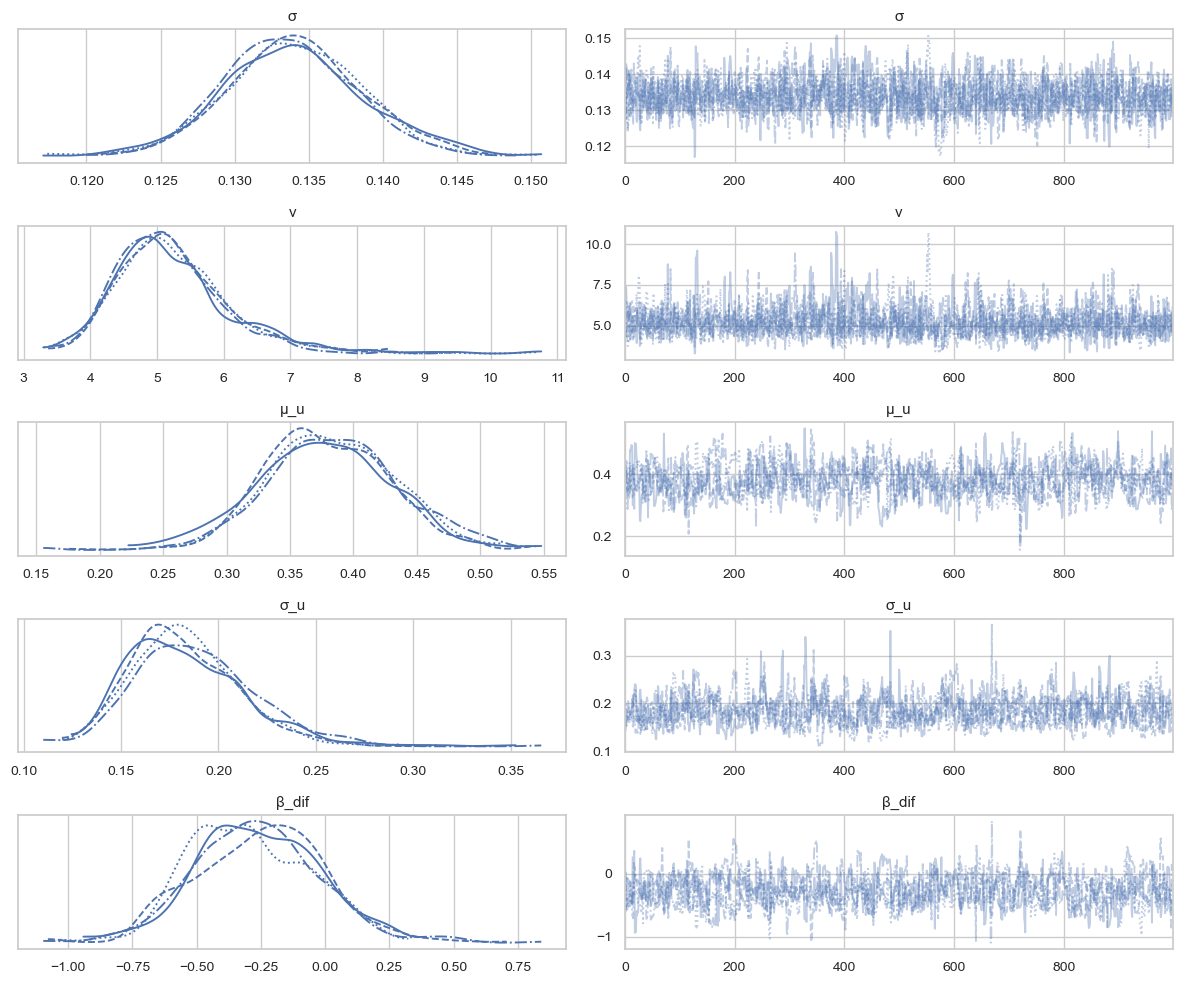

In [ ]:
main_params = ["σ", "ν", "μ_u", "σ_u", "β_dif"]

az.plot_trace(trace_accuracy, var_names=main_params)
plt.tight_layout()
plt.show()

In [ ]:
beta_dif_samples = trace_accuracy.posterior["β_dif"].values

prob_negative = np.mean(beta_dif_samples < 0)

print(f"Probability of β_dif being negative: {prob_negative:.2%}")

Probability of β_dif being negative: 87.00%


$\sigma_u$ ~ HalfNormal(1) <br>
$\mu_u$ ~ Normal(0, 1) <br>
$\beta_{\text{DIF}}$ ~ Normal(0, 1) <br>
<br>
$u_j$ ~ Normal($\mu_u + \beta_{\text{DIF}}$, $\sigma_u$) <br>
<br>
$\nu$ ~ HalfNormal(20) <br>
$\sigma$ ~ InverseGamma(1, 0.5) <br>
VSA Importance ~ StudentT($u_j$, $\sigma$, $\nu$) <br>
<br>
$P(\beta_{\text{DIF}}  <  0 \ | \ Y) = 86.00$

In [ ]:
posterior_summary = az.summary(trace_accuracy, var_names=['β_dif', 'σ', 'ν', 'μ_u', 'σ_u'], round_to=3)
posterior_summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
β_dif,-0.270,0.241,-0.714,0.160,0.010,0.006,561.145,553.190,1.009
σ,0.134,0.005,0.124,0.142,0.000,0.000,1402.117,1280.153,1.005
ν,5.229,0.870,3.861,6.954,0.025,0.032,1334.390,1343.675,1.005
μ_u,0.381,0.051,0.287,0.475,0.002,0.001,508.682,732.783,1.008
σ_u,0.184,0.029,0.136,0.240,0.001,0.001,535.574,928.824,1.005


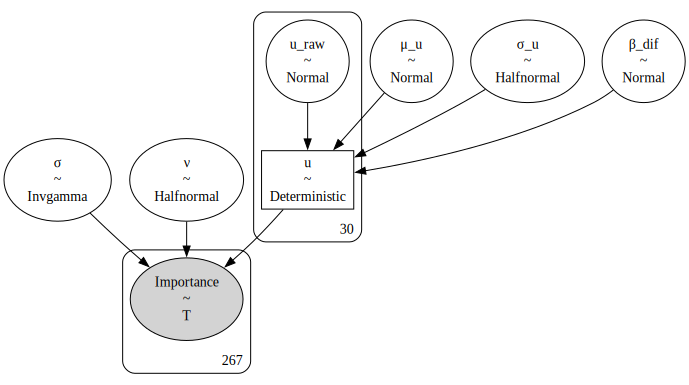

In [ ]:
pm.model_to_graphviz(importance_model)

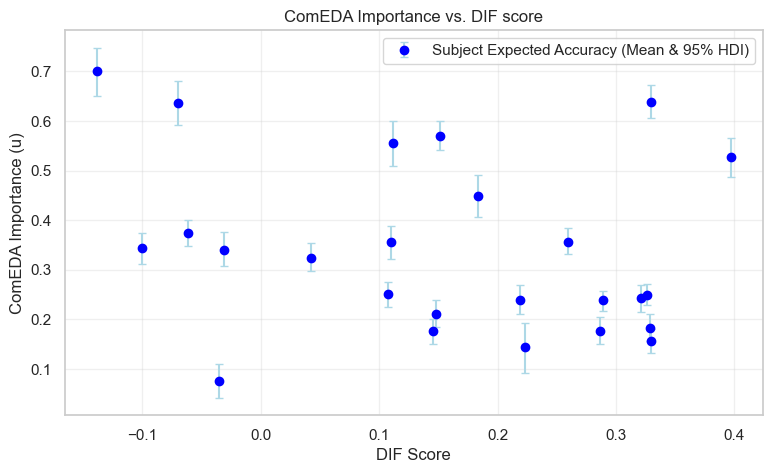

In [ ]:


# Compute the posterior mean and 95% HDI for each subject's baseline expectation 'u'
post_u = trace_accuracy.posterior["u"]
mean_accuracy = post_u.mean(dim=["chain", "draw"]).values
hdi_accuracy = az.hdi(post_u, hdi_prob=0.95)["u"].values

# Calculate symmetric/asymmetric error bars for plt.errorbar
yerr = np.vstack([
    mean_accuracy - hdi_accuracy[:, 0],  # Lower bounds
    hdi_accuracy[:, 1] - mean_accuracy   # Upper bounds
])

noise = np.random.uniform(0, 0.01, difs.__len__())
plt.figure(figsize=(9, 5))
plt.errorbar(
    x=difs + noise, 
    y=mean_accuracy, 
    yerr=yerr, 
    fmt='o', 
    color='blue', 
    ecolor='lightblue', 
    capsize=3,
    label='Subject Expected Accuracy (Mean & 95% HDI)'
)

plt.xlabel("DIF Score")
plt.ylabel("ComEDA Importance (u)")
plt.title("ComEDA Importance vs. DIF score")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Sampling: [Importance]


c:\Users\Mario Tokumori\.conda\envs\handeln2025\lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

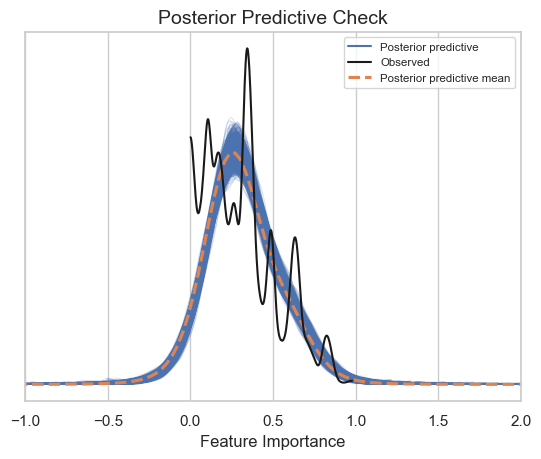

In [ ]:
with importance_model:
    # Generate predicted data based on the posterior traces
    pm.sample_posterior_predictive(trace_accuracy, extend_inferencedata=True)
# Plot the real observed accuracy distribution vs. the model's generated predictions
az.plot_ppc(trace_accuracy)
plt.title("Posterior Predictive Check", fontsize=14)
plt.xlabel("Feature Importance")
plt.xlim(-1, 2)
plt.show()

### Figures


In [179]:
df.columns

Index(['id', 'condition', 'block_acc', 'block_bal_acc', 'loo_acc',
       'loo_bal_acc', 'accuracy', 'block_cv', 'age', 'gender', 'tas', 'eot',
       'ddf', 'dif', 'behavioral_accuracy', 'tas_minus_eot'],
      dtype='object')

ValueError: zero-size array to reduction operation maximum which has no identity

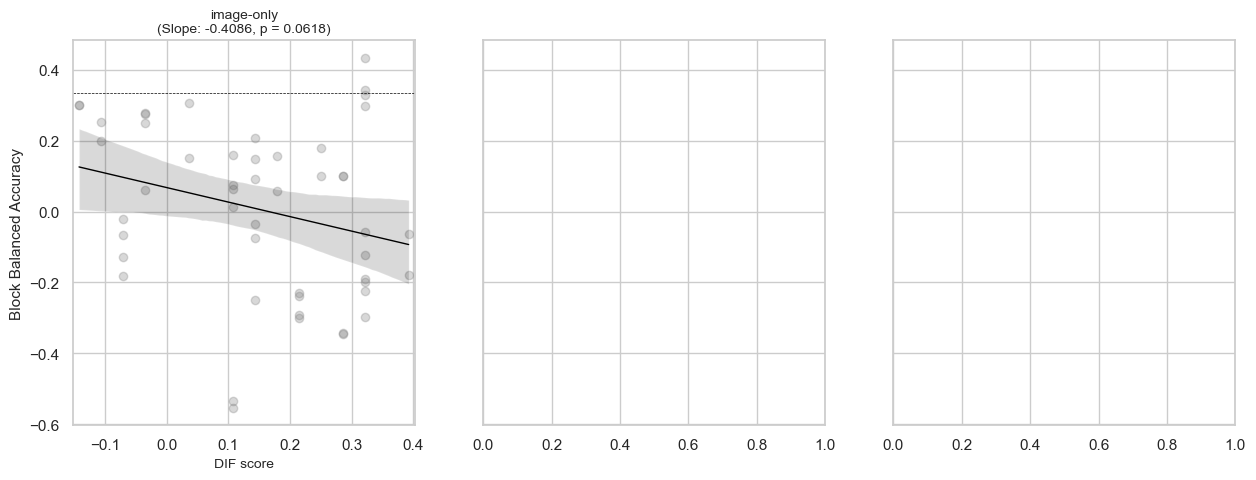

In [574]:
# Define the 3 conditions to loop through
conditions = ['imageonly', 'audioimage']

fixed_effect = 'dif'
acc = 'norm_block_bal_acc'
chance_level = 1/3

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

x_min, x_max = df[fixed_effect].min() - 0.01 , df[fixed_effect].max() + 0.01

for i, condition in enumerate(conditions):
    df_cond = df[df['condition'] == condition]

    # Fit OLS model for this condition
    result = smf.ols(f"{acc} ~ {fixed_effect}", data=df_cond).fit()
    intercept = result.params['Intercept']
    slope = result.params[fixed_effect]
    p_value = result.pvalues[fixed_effect]
    # print(result.summary())
    
    ax = axes[i]    
    sns.regplot(
        x=fixed_effect, 
        y=acc, 
        data=df_cond, 
        scatter_kws={'alpha':0.3, 'color':'gray'},
        line_kws={'color':'black', 'lw':1},
        ax=ax
    )
    
    # Draw the chance level line
    ax.axhline(y=chance_level, color='black', linestyle='--', lw=0.5)

    # Alexithymia threshold line
    # ax.axvline(x=(51-20)/(100-20), color='black', linestyle=':', lw=1.5)
    # ax.axvline(x=(60-20)/(100-20), color='black', linestyle=':', lw=1.5)
    
    # Format condition name for the title string (e.g., 'audioonly' -> 'Audio-Only')
    display_name = condition.replace('only', '-only') if 'only' in condition else condition.replace('image', '+image')
    ax.set_title(f'{display_name}\n'
                 f'(Slope: {slope:.4f}, p = {p_value:.4f})', fontsize=10)
    
    ax.set_xlabel(f'{fixed_effect.upper()} score', fontsize=10)
    
    # Only show the Y label on the leftmost plot since they share the Y axis
    if i == 0:
        ax.set_ylabel('Block Balanced Accuracy', fontsize=11)
    else:
        ax.set_ylabel('')
        
    # Set axis limits
    # ax.set_ylim(0.1, 0.6)
    # ax.set_xlim(0.3, 0.9)
    ax.set_xlim(x_min, x_max)

fig.suptitle('Which Conditions Show a Difference in Normalized Leave-One-Block-Out CV Balanced Accuracy across Alexithymia Levels relative to What Subjects Report?', fontsize=12)

plt.tight_layout()
plt.show()